# Distribution Shift Analysis

Visualize how feature distributions differ between the 630K competition
dataset and the four UCI clinical subsets. This explains why zero-shot
transfer performance varies across datasets.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from src.data_external import load_all_datasets

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
# Load competition data
train = pd.read_csv('../data/competition/train.csv')

features = ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
            'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
            'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

# Load UCI datasets
uci_datasets = load_all_datasets()
print('Loaded datasets:')
for name, (X, y, meta) in uci_datasets.items():
    print(f'  {name}: n={meta["n_samples"]}, prevalence={meta["prevalence"]}%')

Loaded datasets:
  cleveland: n=303, prevalence=45.9%
  hungarian: n=294, prevalence=36.1%
  switzerland: n=123, prevalence=93.5%
  va_longbeach: n=200, prevalence=74.5%


## KS-Test Distribution Shift Heatmap

For each feature and UCI dataset, compute the Kolmogorov-Smirnov statistic
measuring how different the distribution is from the competition data.
Higher values indicate larger distributional shift.

In [3]:
# Compute KS statistic for each feature x dataset combination
ks_matrix = pd.DataFrame(index=features, columns=list(uci_datasets.keys()))

for ds_name, (X_uci, y_uci, meta) in uci_datasets.items():
    for feat in features:
        if feat not in X_uci.columns:
            ks_matrix.loc[feat, ds_name] = np.nan
            continue
        comp_vals = pd.to_numeric(train[feat], errors='coerce').dropna().values
        uci_vals = pd.to_numeric(X_uci[feat], errors='coerce').dropna().values
        if len(uci_vals) == 0:
            ks_matrix.loc[feat, ds_name] = np.nan
            continue
        stat, _ = ks_2samp(comp_vals, uci_vals)
        ks_matrix.loc[feat, ds_name] = round(stat, 3)

ks_matrix = ks_matrix.astype(float)
ks_matrix

,cleveland,hungarian,switzerland,va_longbeach
Age,0.038,0.326,0.104,0.300
Sex,0.035,0.010,0.204,0.255
Chest pain type,0.077,0.234,0.274,0.132
BP,0.058,0.067,0.181,0.164
Cholesterol,0.100,0.130,1.000,0.352
FBS over 120,0.069,0.012,0.039,0.260
EKG results,0.010,0.469,0.433,0.355
Max HR,0.088,0.341,0.541,0.646
Exercise angina,0.053,0.029,0.165,0.466
ST depression,0.173,0.143,0.089,0.440


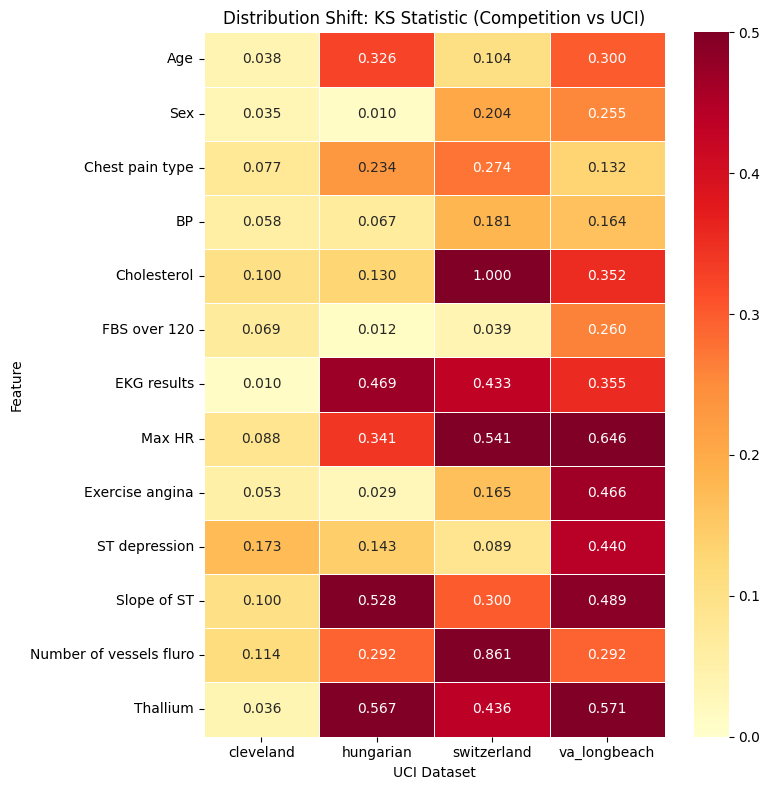

In [4]:
# Heatmap
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(ks_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=0.5, ax=ax, linewidths=0.5)
ax.set_title('Distribution Shift: KS Statistic (Competition vs UCI)')
ax.set_xlabel('UCI Dataset')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../results/figures/distribution_shift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Dataset Shift Summary

In [5]:
# Average KS per dataset
print('Mean KS statistic per dataset (higher = more shift):')
print(ks_matrix.mean().sort_values(ascending=False))

print('\nMost shifted features (mean across datasets):')
print(ks_matrix.mean(axis=1).sort_values(ascending=False).head(5))

Mean KS statistic per dataset (higher = more shift):
va_longbeach    0.363231
switzerland     0.355923
hungarian       0.242154
cleveland       0.073154
dtype: float64

Most shifted features (mean across datasets):
Max HR                     0.40400
Thallium                   0.40250
Cholesterol                0.39550
Number of vessels fluro    0.38975
Slope of ST                0.35425
dtype: float64


## Observations

- Cleveland has the least distributional shift (expected, since the competition
  data was generated from Cleveland via CTGAN)
- Switzerland and VA Long Beach show the most shift, consistent with
  lower zero-shot transfer performance on these datasets
- Features like Cholesterol and BP show the most variation across hospitals,
  reflecting differences in patient populations and measurement protocols
- Thallium and Chest pain type are more stable, explaining their consistent
  predictive value across datasets